## Import the dataset as a dataframe using pandas 

In [251]:
# Note this is a cleaned updatasets form the Perovskite Database Project released in 2022
# 
import pandas as pd

df=pd.read_csv('curated_set_updated_0426.csv')

## For the tutorial, we will use two datasets, a subset from the overall set, just to expedite the training of the ML models and tasks below 

In [252]:
df_clean = df.dropna()
df_subset = df_clean.sample(n=5000, random_state=42).reset_index(drop=True)

max of original 24.66
max of subset 23.0


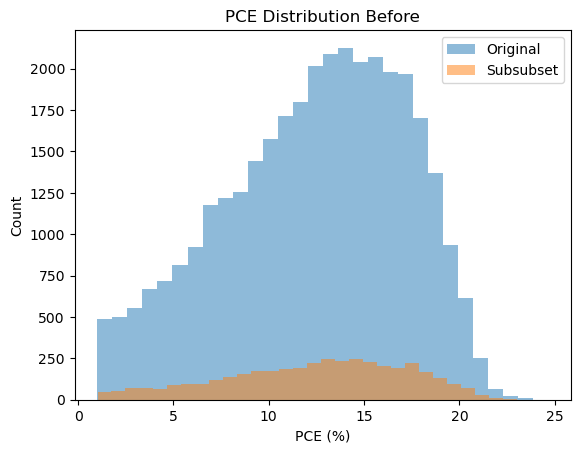

In [236]:
import matplotlib.pyplot as plt

print("max of original", df_clean["JV_reverse_scan_PCE"].max())
print("max of subset", df_subset["JV_reverse_scan_PCE"].max())

# Original distribution
plt.hist(df_clean["JV_reverse_scan_PCE"], bins=30, alpha=0.5, label="Original")

# Subsampled distribution
plt.hist(df_subset["JV_reverse_scan_PCE"], bins=30, alpha=0.5, label="Subsubset")

plt.xlabel("PCE (%)")
plt.ylabel("Count")
plt.title("PCE Distribution Before")
plt.legend()
plt.show()

## To approximate a materials discovery task, we will take only the lowest subset of the distribution and try to rediscover new high performing materials  

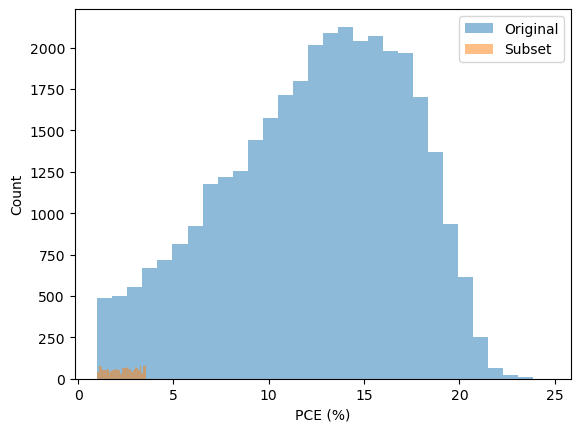

In [119]:

target_col = "JV_reverse_scan_PCE"
# lowest 20 %, can try 10% or 50%, etc. to see how it affects the result 
p = 0.05
X_low, X_pool, y_low, y_pool = split_by_percentile(df_clean, target_col, p)

# Original distribution
plt.hist(df_clean["JV_reverse_scan_PCE"], bins=30, alpha=0.5, label="Original")

# Subsampled distribution
plt.hist(y_low, bins=30, alpha=0.5, label="Subset")

plt.xlabel("PCE (%)")
plt.ylabel("Count")
# plt.title("PCE Distribution Before")
plt.legend()
plt.show()


## Let's train an initial ML model to the subset dataset spanning the entire distribution which we will call the pre-trained model  

Best params: {'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
test
RMSE: 2.732
MAE: 2.063
R²: 0.663
train
RMSE: 2.446
MAE: 1.868
R²: 0.735


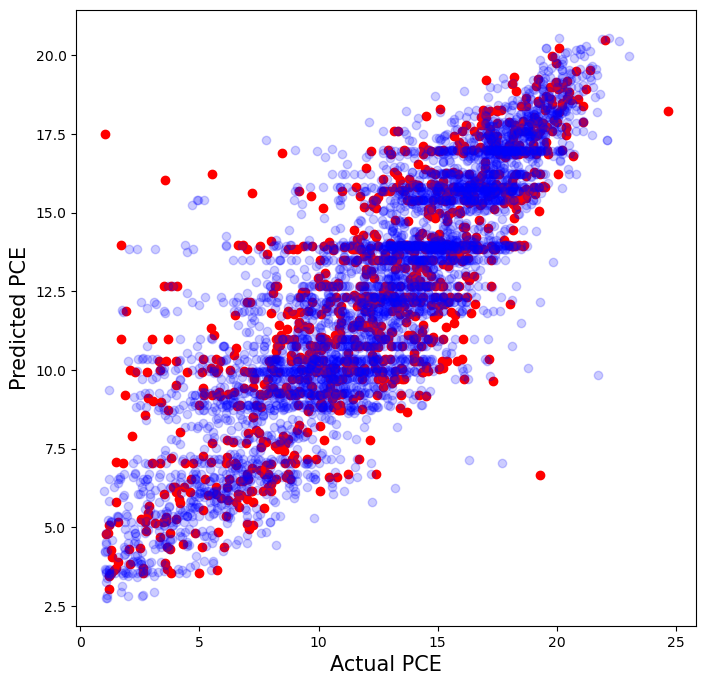

In [247]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

target_col = 'JV_reverse_scan_PCE'

# Inputs
X = df_subset.drop(columns=[target_col])

# Predictions/target 
y = df_subset[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt"]  #"log2"
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

bestmodel = search.best_estimator_
print("Best params:", search.best_params_)

y_pred = bestmodel.predict(X_test)
y_pred_train = bestmodel.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('test')
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

print('train')
y_pred_train = bestmodel.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

plt.figure(figsize=(8,8))
plt.scatter(y_test,y_pred,marker='o',color='r',label='Test Data')
plt.scatter(y_train,y_pred_train,color='b',alpha=0.2,label='Train Data')
plt.xlabel(xlabel='Actual PCE',fontsize=15)
plt.ylabel(ylabel='Predicted PCE',fontsize=15)

plt.show()


In [151]:
def split_by_percentile(df, target_col, percentile):
    threshold = df[target_col].quantile(percentile)

    df_low = df[df[target_col] <= threshold].reset_index(drop=True)
    df_high = df[df[target_col] > threshold].reset_index(drop=True)

    X_low = df_low.drop(columns=["JV_reverse_scan_PCE"])
    y_low = df_low["JV_reverse_scan_PCE"].values

    X_high = df_high.drop(columns=["JV_reverse_scan_PCE"])
    y_high = df_high["JV_reverse_scan_PCE"].values

    return X_low, X_high, y_low, y_high

target_col = "JV_reverse_scan_PCE"
# lowest 20 %, can try 10% or 50%, etc. to see how it affects the result 
p = 0.2
X_low, X_high, y_low, y_high = split_by_percentile(df_subset, target_col, p)

print("Low:", X_low.shape)
print("High:", X_high.shape)

Low: (2019, 24)
High: (7981, 24)


## As a baseline comparison, we will compare with randomly navigating the space 

In [120]:
def random_subspace(X_high, y_high, y_init, cols, steps=30, first_idx=None):
    from sklearn.neighbors import NearestNeighbors
    import numpy as np 

    X_sub = X_high[cols].values
    nn = NearestNeighbors(n_neighbors=1).fit(X_sub)

    mins = X_sub.min(axis=0)
    maxs = X_sub.max(axis=0)

    rand_y = y_init.copy()
    best = []
    random_guess = []
    used = set()

    for step in range(steps):
        if step == 0 and first_idx is not None:
            idx = first_idx
        else:
            while True:
                    point = np.random.uniform(mins, maxs)
                    idx = nn.kneighbors(point.reshape(1, -1))[1][0][0]

                    if idx not in used:
                        break

        used.add(idx)

        rand_y = np.append(rand_y, y_high[idx])
        random_guess.append( y_high[idx] )         
        best.append(rand_y.max())
    
    return best, random_guess


## Now let's see how the BO works for the random sampling 

your choice of columns to try Index(['Numb_A', 'Numb_B', 'Numb_X', 'per_inorg_Asite', 'tau', 'max_rA',
       'max_rX', 'max_rB', 'min_rA', 'min_rB', 'min_rX', 'avg_rA', 'avg_rB',
       'avg_rX', 'std_rA', 'std_rB', 'std_rX', 'diff_min-max_rA',
       'diff_min-max_rB', 'diff_min-max_rX', 'proj_Eg', 'std_eg',
       'JV_reverse_scan_Voc', 'diff_Eg_Voc'],
      dtype='object')


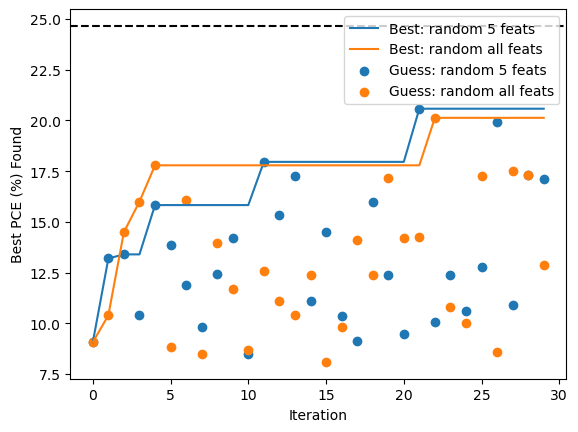

In [156]:
#make sure the experiment is initialized correctly first 
np.random.seed(2)
tmp_first_idx = np.random.randint(len(X_high))

print("your choice of columns to try", X_high.columns)
incols = ['proj_Eg', 'std_eg', 'per_inorg_Asite', 'tau', 'max_rA']
tmp_random1, tmp_guess1 = random_subspace(X_high, y_high, y_low, cols=incols, steps=30, first_idx=tmp_first_idx)

incols = list(X_high.columns) 
tmp_random2, tmp_guess2 =  random_subspace(X_high, y_high, y_low, cols=incols, steps=30,  first_idx=tmp_first_idx)

plt.plot([i for i in range(len(tmp_random1))], tmp_random1, label="Best: random 5 feats")
plt.plot([i for i in range(len(tmp_random2))], tmp_random2, label="Best: random all feats")

plt.scatter([i for i in range(len(tmp_guess1))], tmp_guess1, label="Guess: random 5 feats")
plt.scatter([i for i in range(len(tmp_guess2))], tmp_guess2, label="Guess: random all feats")


plt.axhline(y=24.66, color='black', linestyle='--')

plt.xlabel("Iteration")
plt.ylabel("Best PCE (%) Found")
plt.legend()
plt.show()



## Below is the framework for the BO coded by hand. This requires calculating the mu and sigma for two different model classes (random forest and gaussian process regression)

In [230]:

def get_mu_sigma(model, X, model_type="rf"):
    if model_type == "rf":
        preds = np.stack([tree.predict(X) for tree in model.estimators_])
        mu = preds.mean(axis=0)
        sigma = preds.std(axis=0)
    elif model_type == "gp":
        mu, sigma = model.predict(X, return_std=True)
        
    else:
        raise ValueError("model_type must be 'rf' or 'gp'")
    
    return mu, sigma

def acquisition_ucb(X, model, model_type="rf", kappa=2.0):
    mu, sigma = get_mu_sigma(model, X, model_type)
    return mu + kappa * sigma

def run_bo(X_low, y_low, X_high, y_high, model,
           model_type='rf', steps=30, kappa=2.0,
           first_idx=None, retrain=True):

    prediction_error = []
    sigmas = []
    best = []

    observed_X = X_low.values.copy()
    observed_y = y_low.copy()
    remaining_X = X_high.copy()
    remaining_y = y_high.copy()

    for step in range(steps):

        #fit model 
        if retrain:
            model.fit(observed_X, observed_y)

        # predict pool
        mu_out, sigma_out = get_mu_sigma(
            model, remaining_X.values, model_type
        )
        
        # select next points
        if step == 0 and first_idx is not None:
            idx = first_idx
        else:
            scores = mu_out + kappa * sigma_out  # UCB 
            idx = np.argmax(scores)

        x_new = remaining_X.iloc[idx]
        y_new = remaining_y[idx]

        # record differences in predictions 
        error_next = mu_out[idx] - y_new
        prediction_error.append(error_next)
        sigmas.append(sigma_out[idx])

        print("sigma at selected point:", sigma_out[idx])

        # update observed set for next loop of the retraining 
        observed_X = np.vstack([observed_X, x_new.values])
        observed_y = np.append(observed_y, y_new)

        # remove from pool for next loop
        remaining_X = remaining_X.drop(
            index=remaining_X.index[idx]
        ).reset_index(drop=True)

        remaining_y = np.delete(remaining_y, idx)

        best.append(observed_y.max())

    return best, prediction_error, sigmas


### Now we're ready to compare these different approaches 

In [245]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

target_col = "JV_reverse_scan_PCE"
# lowest 20 %, can try 10% or 50%, etc. to see how it affects the result 
p = 0.05
X_low, X_pool, y_low, y_pool = split_by_percentile(df_clean, target_col, p)

print("Low:", X_low.shape)
print("High:", X_pool.shape)

#let's grab the same smaple to intilizate all of these campaigns
np.random.seed(42)
first_idx = np.random.randint(len(X_pool))
#can try different seeds 

rf_model = RandomForestRegressor(
                        n_estimators=400,
                        min_samples_split=2,
                        min_samples_leaf=2,
                        max_features='sqrt',
                        max_depth=10,
                        n_jobs=-1
                    )

# RF BO
rf_bo_curve_pt, rf_bo_errors_pt, rf_bo_sigmas_pt = run_bo(X_low, y_low, X_pool, y_pool, bestmodel, model_type="rf", kappa=4.0, first_idx=first_idx, retrain=False)

# RF BO
rf_bo_curve, rf_bo_errors, rf_bo_sigmas = run_bo(X_low, y_low, X_pool, y_pool, rf_model, model_type="rf", kappa=3.0, first_idx=first_idx, retrain=True)

# GPR BO
kernel =  Matern(length_scale=1.0, nu=2.5) + WhiteKernel()
gpr_model = GaussianProcessRegressor(kernel)
gp_bo_curve, gp_bo_errors, gp_bo_sigmas = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", kappa=6.0, first_idx=first_idx, retrain=True)

print("your choice of columns to try", X_high.columns)
incols = ['proj_Eg', 'std_eg', 'per_inorg_Asite', 'tau', 'max_rA']
best1, guess1 = random_subspace(X_pool, y_pool, y_low, cols=incols, first_idx=first_idx)

incols = list(X_high.columns) #['proj_Eg', 'std_eg',]
best2, guess2 = random_subspace(X_pool, y_pool, y_low, cols=incols, first_idx=first_idx)

# incols = ['max_rA']
# subspace_curve3 =  random_subspace(X_pool, y_pool, y_low, cols=incols, first_idx=first_idx)


Low: (1708, 24)
High: (32406, 24)
sigma at selected point: 1.2512566904197915
sigma at selected point: 4.202614131862225
sigma at selected point: 3.2123668016131983
sigma at selected point: 4.341260250070427
sigma at selected point: 3.1975615501520025
sigma at selected point: 3.1975615501520025
sigma at selected point: 3.1975615501520025
sigma at selected point: 3.1857999418758274
sigma at selected point: 4.278854360454652
sigma at selected point: 4.367532708302933
sigma at selected point: 5.064900967261283
sigma at selected point: 5.010344095907862
sigma at selected point: 5.009815637098845
sigma at selected point: 3.8590113968806934
sigma at selected point: 3.3342546088471754
sigma at selected point: 5.231646293052245
sigma at selected point: 5.231646293052245
sigma at selected point: 5.231646293052245
sigma at selected point: 5.231646293052245
sigma at selected point: 5.262504301806476
sigma at selected point: 5.262504301806476
sigma at selected point: 3.3702980981225537
sigma at se

## Let's plot the error of the ML mdoels at each step to see how it's perfroming 

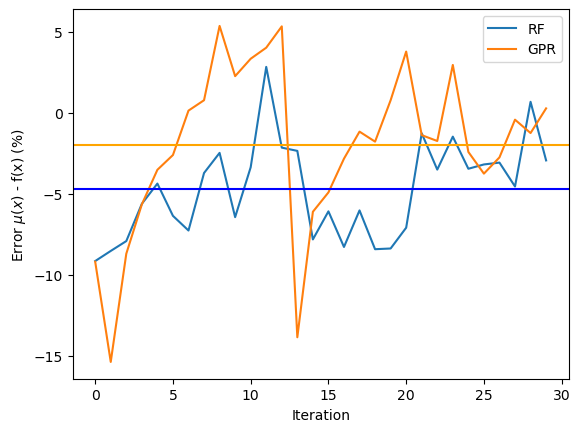

In [239]:

plt.plot([i for i in range(len(rf_bo_errors))], rf_bo_errors, label="RF")
plt.plot([i for i in range(len(gp_bo_errors))], gp_bo_errors, label="GPR")
# plt.plot([i for i in range(len(rf_bo_errors_pt))], rf_bo_errors_pt, label="RF PT")

plt.axhline(y=np.mean(rf_bo_errors), linestyle='-', color = "blue")
plt.axhline(y=np.mean(gp_bo_errors), linestyle='-', color = "orange")
# plt.axhline(y=np.mean(rf_bo_errors_pt), linestyle='-', color = "green")


plt.xlabel("Iteration")
plt.ylabel(r"Error $\mu(x)$ - f(x) (%) ")
plt.legend()
plt.show()



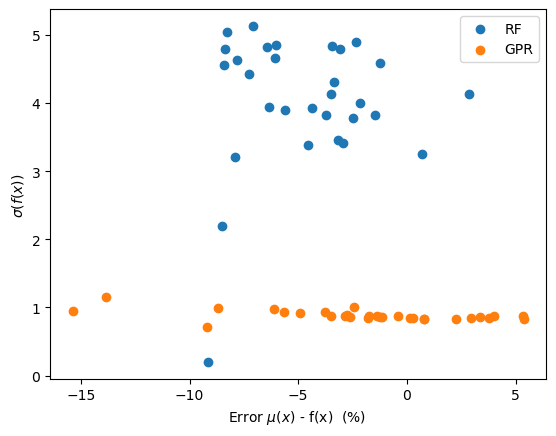

In [241]:
plt.scatter(rf_bo_errors, rf_bo_sigmas, label="RF")
plt.scatter(gp_bo_errors, gp_bo_sigmas, label="GPR")
# plt.scatter(rf_bo_errors_pt, rf_bo_sigmas_pt, label="RF PT")

plt.xlabel(r"Error $\mu(x)$ - f(x)  (%) ")
plt.ylabel(r"$\sigma (f(x)$) ")
plt.legend()
plt.show()


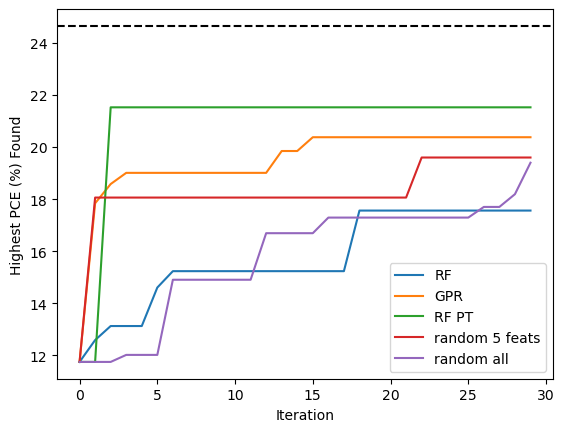

In [246]:
plt.plot([i for i in range(len(rf_bo_curve))], rf_bo_curve, label="RF")
plt.plot([i for i in range(len(rf_bo_curve))], gp_bo_curve, label="GPR")
plt.plot([i for i in range(len(rf_bo_curve_pt))], rf_bo_curve_pt, label="RF PT")
plt.plot([i for i, _ in enumerate(best1)], best1, label="random 5 feats")
plt.plot([i for i, _ in enumerate(best2)], best2, label="random all")
# plt.plot([i for i in range(len(subspace_curve3))], subspace_curve3, label="random 1 feat")

plt.axhline(y=24.66, color='black', linestyle='--')
plt.xlabel("Iteration")
plt.ylabel("Highest PCE (%) Found")
plt.legend()
plt.show()

In [ ]:
# RF BO
rf_bo_curve_pt_100steps = run_bo(X_low, y_low, X_pool, y_pool, bestmodel, model_type="rf", steps=100, kappa=3.0, first_idx=first_idx, retrain=False)

# RF BO
rf_bo_curve_100steps = run_bo(X_low, y_low, X_pool, y_pool, rf_model, model_type="rf", steps=100, kappa=3.0, first_idx=first_idx, retrain=True)

# GPR BO
gpr_model = GaussianProcessRegressor(kernel=Matern(nu=2.5))
gp_bo_curve_100steps = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=3.0, first_idx=first_idx, retrain=True)

print("your choice of columns to try", X_high.columns)
incols = ['proj_Eg', 'std_eg', 'per_inorg_Asite', 'tau', 'max_rA']
subspace_curve1_100steps = random_subspace(X_pool, y_pool, y_low, cols=incols, steps = 100, first_idx=first_idx)

incols = list(X_high.columns) #['proj_Eg', 'std_eg',]
subspace_curve2_100steps =  random_subspace(X_pool, y_pool, y_low, cols=incols, steps = 100, first_idx=first_idx)



### Below, is an example of different kappas values in the UCB framework 

In [ ]:
# test the effectiveness of different kappa values for GPR

gpr_model = GaussianProcessRegressor(kernel=Matern(nu=2.5))
gp_bo_curve_100steps_kappa1pt0 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=1.0, first_idx=first_idx, retrain=True)

gp_bo_curve_100steps_kappa0pt5 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=0.5, first_idx=first_idx, retrain=True)

gp_bo_curve_100steps_kappa2pt0 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=2.0, first_idx=first_idx, retrain=True)

gp_bo_curve_100steps_kappa3pt0 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=3.0, first_idx=first_idx, retrain=True)

gp_bo_curve_100steps_kappa5pt0 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=5.0, first_idx=first_idx, retrain=True)

gp_bo_curve_100steps_kappa10pt0 = run_bo(X_low, y_low, X_pool, y_pool, gpr_model, model_type="gp", steps=100, kappa=10.0, first_idx=first_idx, retrain=True)


#### Now on your own, try these things: 
####  1) Modify k (lower or higher), do you have a higher success than random?
####  2) Modify the training sets, explore whether the accuracy of the model or the size of the space increasing affects how quickly you find new samples